# Mechanical Parts Segmentation — Cluttered Tray, 6 Classes, From Scratch

**Task:** pixel-level semantic segmentation of a workbench photo into 6 fastener
classes (`hex_nut`, `washer`, `bolt`, `ball_bearing`, `spring`, `o_ring`) plus
background, scored by mean Dice over every (image, class) pair.

**Constraint:** no pretrained weights of any kind — every parameter in this
notebook is randomly initialised (Kaiming/Xavier) and trained only on the
2,000 provided training images. This shapes almost every choice below: a
compact U-Net trained from scratch needs more epochs, heavier augmentation,
and a training-stability-first setup compared to a fine-tuned backbone.

This notebook follows the required workflow:
1. Understand the problem
2. Explore the dataset (EDA)
3. Preprocessing (RLE ↔ mask utilities, dataset class, augmentation)
4. Model development (from-scratch U-Net + combined loss)
5. Training (with monitoring of loss/Dice, from-scratch-appropriate schedule)
6. Generate predictions (TTA inference → `submission.csv`)


## Step 1 — Understand the problem

- Input: 384×384 RGB images of a cluttered parts tray.
- Output: a per-pixel class id (0 = background, 1–6 = the six part classes).
- Every class appears in every image (1–3 instances each), so this is not a
  detection problem with missing classes — it's about getting the *boundary*
  right between visually similar shapes (hex vs round, thin vs thick ring)
  and coping with occlusion where parts pile on top of each other.
- Metric: mean Dice averaged over all (image, class) pairs. Two consequences
  that shape the whole pipeline:
  - **Predicting a class that isn't present costs a full point**, same as
    missing a class that is present — so the model must not hallucinate
    small confident blobs of the wrong class.
  - Dice is computed **per class independently**, so a model that nails 5
    classes and collapses on the rarest one (usually `spring` or `o_ring`,
    since they're thin) still loses a full 1/6 of the score on every image.
    A weighted loss + per-class validation monitoring both target this
    directly.


In [18]:
import os, glob, random, time, math
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------------- Config ----------------
class CFG:
    root = "/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset"
    out_dir = "/kaggle/working"
    size = 384
    classes = ["hex_nut", "washer", "bolt", "ball_bearing", "spring", "o_ring"]
    num_classes = len(classes) + 1  # + background
    seed = 42
    batch_size = 24
    epochs = 50
    lr = 3e-4
    warmup_epochs = 5
    base_channels = 32
    val_frac = 0.15
    num_workers = 2
    amp = True

CLASSES = CFG.classes
CLASS_ID = {c: i + 1 for i, c in enumerate(CLASSES)}

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
os.makedirs(CFG.out_dir, exist_ok=True)


device: cuda


## Step 2 — Explore the dataset

We look at:
- train/test split sizes and background-surface variety (`metadata.csv`)
- per-class presence, typical pixel area, and instance count (a proxy for
  how hard each class will be — small/rare classes need loss weighting)
- a handful of images with their ground-truth masks overlaid


(2500, 5)
              id  split background  n_parts  \
0  img_00000.png  train       wood     10.0   
1  img_00001.png   test        NaN      NaN   
2  img_00002.png  train   concrete     10.0   
3  img_00003.png  train   concrete      7.0   
4  img_00004.png  train   concrete      6.0   

                                  classes_present  
0  hex_nut;washer;bolt;ball_bearing;spring;o_ring  
1                                             NaN  
2  hex_nut;washer;bolt;ball_bearing;spring;o_ring  
3  hex_nut;washer;bolt;ball_bearing;spring;o_ring  
4  hex_nut;washer;bolt;ball_bearing;spring;o_ring  

split counts:
split
train    2000
test      500
Name: count, dtype: int64

background surface distribution (train only):
background
brushed_metal    513
concrete         501
woven_fabric     497
wood             489
Name: count, dtype: int64


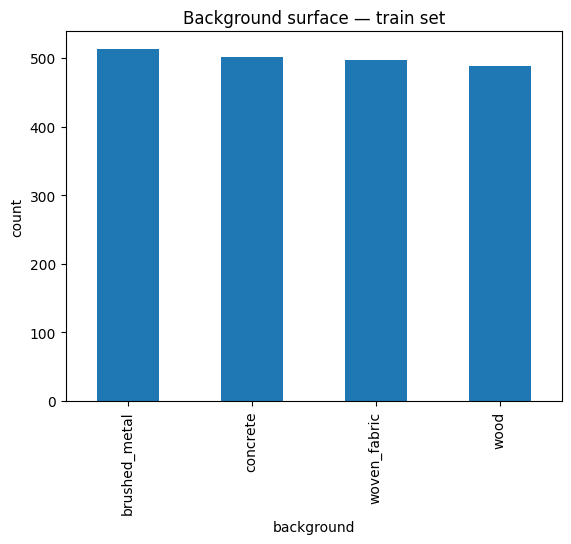

In [19]:
meta = pd.read_csv(f"{CFG.root}/metadata.csv")
print(meta.shape)
print(meta.head())

print("\nsplit counts:")
print(meta["split"].value_counts())

print("\nbackground surface distribution (train only):")
print(meta[meta.split == "train"]["background"].value_counts())

meta[meta.split == "train"]["background"].value_counts().plot(kind="bar", title="Background surface — train set")
plt.ylabel("count")
plt.show()


In [20]:
train_csv = pd.read_csv(f"{CFG.root}/train/train.csv")
print(train_csv.shape, "rows  (2000 images x 6 classes =", 2000*6, "expected)")
train_csv.head()


(12000, 2) rows  (2000 images x 6 classes = 12000 expected)


,ImageId_ClassId,EncodedPixels
0,img_00000.png_hex_nut,111619 3 112001 6 112380 2 112383 9 112750 4 1...
1,img_00000.png_washer,24397 1 24403 1 24778 14 25158 21 25539 27 259...
2,img_00000.png_bolt,1049 1 1051 1 1053 1 1430 10 1811 17 2194 20 2...
3,img_00000.png_ball_bearing,23722 1 24093 16 24473 24 24855 29 25236 33 25...
4,img_00000.png_spring,35446 2 35449 1 35827 9 36208 16 36589 20 3697...


In [21]:
SIZE = CFG.size

def rle_decode(rle, size=SIZE):
    m = np.zeros(size * size, np.uint8)
    if not isinstance(rle, str) or not rle.strip():
        return m.reshape(size, size, order="F")
    a = np.asarray(rle.split(), np.int64)
    for s, l in zip(a[0::2], a[1::2]):
        m[s - 1: s - 1 + l] = 1
    return m.reshape(size, size, order="F")

# per-class stats on a sample of train images (mirrors baseline_starter.py's EDA)
train_csv["img"] = train_csv["ImageId_ClassId"].str.extract(r"(.+\.png)_.+")
train_csv["cls"] = train_csv["ImageId_ClassId"].str.extract(r".+\.png_(.+)")

sample_ids = sorted(meta[meta.split == "train"]["id"])[:200]
rows = []
for c in CLASSES:
    sub = train_csv[(train_csv["cls"] == c) & (train_csv["img"].isin(sample_ids))]
    areas, ninst = [], []
    for _, r in sub.iterrows():
        m = rle_decode(r["EncodedPixels"])
        if m.any():
            areas.append(int(m.sum()))
            n, _ = cv2.connectedComponents(m, 8)
            ninst.append(n - 1)
    rows.append({
        "class": c,
        "present_%": 100 * len(areas) / len(sample_ids),
        "median_px": np.median(areas) if areas else 0,
        "median_instances": np.median(ninst) if ninst else 0,
    })
stats_df = pd.DataFrame(rows)
print(stats_df)


          class  present_%  median_px  median_instances
0       hex_nut      100.0     2984.5               1.0
1        washer      100.0     4260.5               1.0
2          bolt      100.0     8083.0               1.0
3  ball_bearing      100.0     5609.0               1.0
4        spring      100.0     7917.0               1.0
5        o_ring      100.0     3321.0               1.0


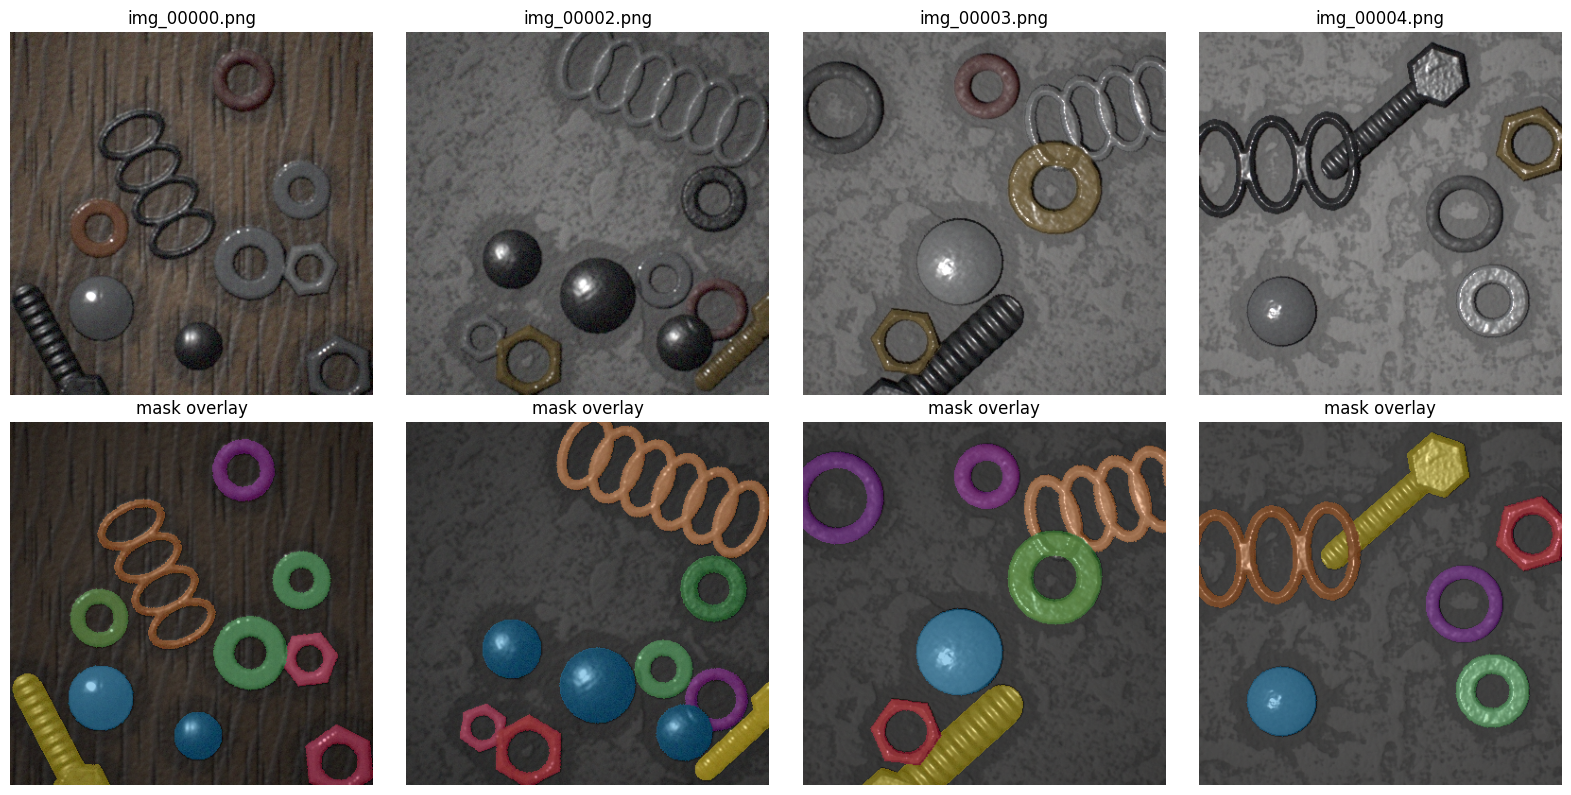

In [22]:
# visualize a few train images with their ground-truth mask overlaid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_show = sample_ids[:4]
palette = np.array([
    [0, 0, 0], [230, 25, 75], [60, 180, 75], [255, 225, 25],
    [0, 130, 200], [245, 130, 48], [145, 30, 180],
], dtype=np.uint8)

for i, fid in enumerate(sample_show):
    img = np.array(Image.open(f"{CFG.root}/train/images/{fid}").convert("RGB"))
    mask = np.array(Image.open(f"{CFG.root}/train/masks/{fid}"))
    overlay = img.copy()
    color_mask = palette[mask]
    overlay = (0.6 * img + 0.4 * color_mask).astype(np.uint8)
    axes[0, i].imshow(img); axes[0, i].set_title(fid); axes[0, i].axis("off")
    axes[1, i].imshow(overlay); axes[1, i].set_title("mask overlay"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## Step 3 — Preprocessing

- RLE encode/decode and the official Dice metric, kept identical to
  `baseline_starter.py` so validation scores here match the leaderboard
  computation exactly.
- A stratified-by-id train/val split (same 85/15 split logic as the starter,
  same seed) so validation numbers are comparable across experiments.
- Augmentation is the main lever available *because* pretrained weights are
  banned — there's no borrowed visual prior, so the model has to learn
  rotation/occlusion invariance entirely from what augmentation provides:
  - random flips + 90°-multiple rotations (parts are arbitrarily oriented)
  - mild brightness/contrast jitter that avoids blowing out specular
    highlights (needed to tell matte `o_ring` from shiny `washer`, and to
    keep the bearing's highlight visible)
  - **copy-paste augmentation**: cut a real instance (via connected
    components) from a donor training image and paste it into another,
    directly synthesizing more occlusion/clutter variety than the raw
    2,000 images contain on their own.


In [23]:
def rle_encode(mask):
    px = np.asarray(mask, np.uint8).T.flatten()
    px = np.concatenate([[0], px, [0]])
    runs = np.where(px[1:] != px[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(int(x)) for x in runs)

def dice_binary(pred, gt):
    p, g = int(np.sum(pred)), int(np.sum(gt))
    if g == 0:
        return 1.0 if p == 0 else 0.0
    if p == 0:
        return 0.0
    return 2.0 * float(np.logical_and(pred, gt).sum()) / (p + g)

def mean_dice_metric(pred_labels, gt_labels):
    """Official competition metric: mean Dice over every (image, class) pair."""
    s = []
    for p, g in zip(pred_labels, gt_labels):
        for cid in range(1, len(CLASSES) + 1):
            s.append(dice_binary(p == cid, g == cid))
    return float(np.mean(s))


In [24]:
tr_ids_all = sorted(meta[meta.split == "train"]["id"])
te_ids = sorted(meta[meta.split == "test"]["id"])

rng = np.random.default_rng(0)
val_ids = list(rng.choice(tr_ids_all, int(len(tr_ids_all) * CFG.val_frac), replace=False))
fit_ids = [i for i in tr_ids_all if i not in set(val_ids)]
print(f"train {len(fit_ids)}   val {len(val_ids)}   test {len(te_ids)}")


train 1700   val 300   test 500


In [25]:
NUM_CLASSES = CFG.num_classes

def color_jitter(img, brightness=0.15, contrast=0.15):
    img = img.astype(np.float32)
    b = 1.0 + np.random.uniform(-brightness, brightness)
    c = 1.0 + np.random.uniform(-contrast, contrast)
    mean = img.mean()
    img = (img - mean) * c + mean
    img = img * b
    return np.clip(img, 0, 255).astype(np.uint8)

class PartsDataset(Dataset):
    def __init__(self, root, ids, train=True, copy_paste_p=0.5):
        self.root, self.ids, self.train, self.copy_paste_p = root, ids, train, copy_paste_p

    def __len__(self):
        return len(self.ids)

    def _load(self, fid):
        img = np.array(Image.open(f"{self.root}/train/images/{fid}").convert("RGB"))
        mask = np.array(Image.open(f"{self.root}/train/masks/{fid}"))
        return img, mask

    def _copy_paste(self, img, mask):
        donor_fid = self.ids[np.random.randint(0, len(self.ids))]
        d_img, d_mask = self._load(donor_fid)
        present = [c for c in range(1, NUM_CLASSES) if (d_mask == c).any()]
        if not present:
            return img, mask
        cid = present[np.random.choice(len(present))]
        comp_mask = (d_mask == cid).astype(np.uint8)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(comp_mask, 8)
        if n <= 1:
            return img, mask
        inst_idx = np.random.randint(1, n)
        x, y, w, h, area = stats[inst_idx]
        if area < 20:
            return img, mask
        inst_mask = (labels == inst_idx).astype(np.uint8)
        patch_img = d_img[y:y + h, x:x + w]
        patch_mask = inst_mask[y:y + h, x:x + w]
        H, W = mask.shape
        if h >= H or w >= W:
            return img, mask
        ty, tx = np.random.randint(0, H - h), np.random.randint(0, W - w)
        img, mask = img.copy(), mask.copy()
        region_img, region_mask = img[ty:ty + h, tx:tx + w], mask[ty:ty + h, tx:tx + w]
        keep = patch_mask.astype(bool)
        region_img[keep] = patch_img[keep]
        region_mask[keep] = cid
        img[ty:ty + h, tx:tx + w] = region_img
        mask[ty:ty + h, tx:tx + w] = region_mask
        return img, mask

    def _augment(self, img, mask):
        if np.random.rand() < self.copy_paste_p:
            img, mask = self._copy_paste(img, mask)
        if np.random.rand() < 0.5:
            img, mask = np.ascontiguousarray(img[:, ::-1]), np.ascontiguousarray(mask[:, ::-1])
        if np.random.rand() < 0.5:
            img, mask = np.ascontiguousarray(img[::-1, :]), np.ascontiguousarray(mask[::-1, :])
        k = np.random.randint(0, 4)
        if k:
            img, mask = np.ascontiguousarray(np.rot90(img, k)), np.ascontiguousarray(np.rot90(mask, k))
        if np.random.rand() < 0.7:
            img = color_jitter(img)
        return img, mask

    def __getitem__(self, idx):
        fid = self.ids[idx]
        img, mask = self._load(fid)
        if self.train:
            img, mask = self._augment(img, mask)
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5
        img_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask_t = torch.from_numpy(mask.astype(np.int64))
        return img_t, mask_t, fid

train_ds = PartsDataset(CFG.root, fit_ids, train=True, copy_paste_p=0.5)
val_ds = PartsDataset(CFG.root, val_ids, train=False)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                           num_workers=CFG.num_workers, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                         num_workers=CFG.num_workers)

img_t, mask_t, fid = train_ds[0]
print("sample shapes:", img_t.shape, mask_t.shape, "labels present:", mask_t.unique().tolist())


sample shapes: torch.Size([3, 384, 384]) torch.Size([384, 384]) labels present: [0, 1, 2, 3, 4, 5, 6]


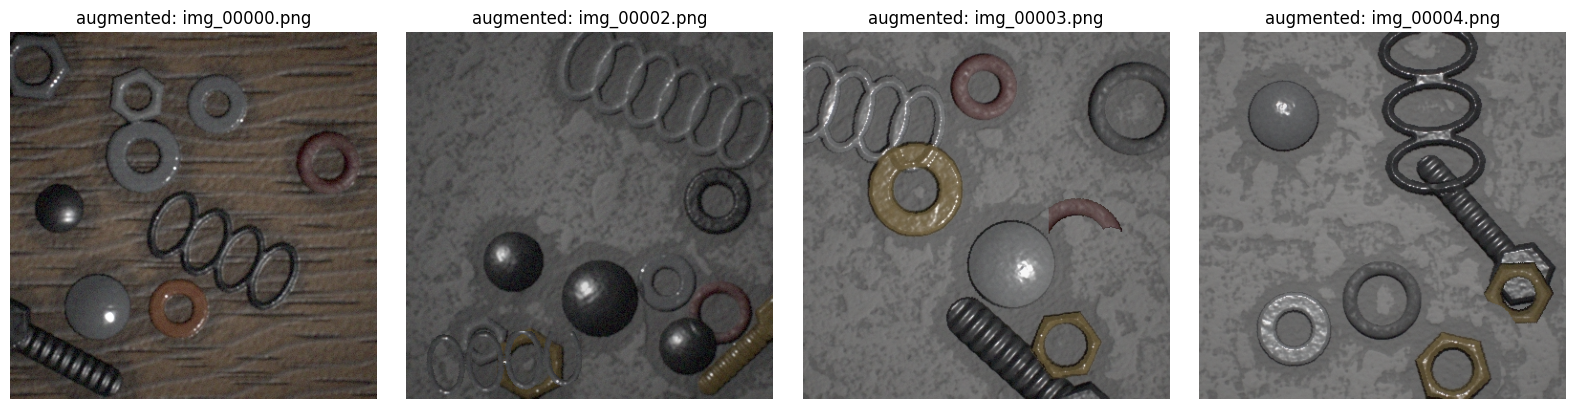

In [26]:
# sanity-check: visualize a few augmented training samples (copy-paste should be visible sometimes)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img_t, mask_t, fid = train_ds[i]
    img_np = ((img_t.numpy().transpose(1, 2, 0) * 0.5 + 0.5) * 255).astype(np.uint8)
    axes[i].imshow(img_np); axes[i].set_title(f"augmented: {fid}"); axes[i].axis("off")
plt.tight_layout()
plt.show()


## Step 4 — Model development

**From-scratch U-Net.** Since ImageNet-pretrained encoders are disallowed,
the architecture favors stability over raw capacity:
- GroupNorm (not BatchNorm) at every conv — more stable with the batch sizes
  a single GPU allows here, and doesn't depend on running statistics that
  are harder to learn well from scratch.
- Kaiming-normal init on every conv, matching the "random initialisation
  expected" rule.
- **Deep supervision**: auxiliary prediction heads at two decoder scales,
  added to the loss with smaller weights, to keep gradients flowing well
  into the encoder — this partially substitutes for the gradient signal a
  pretrained encoder would otherwise already carry.

**Loss.** Combined weighted cross-entropy + macro (per-class-averaged) soft
Dice:
- Class weights are inverse-sqrt of pixel frequency, computed once from the
  training masks, so background (which dominates pixel count) doesn't drown
  out thin classes like `spring`/`o_ring` in the CE term.
- Macro Dice mirrors the *actual* scoring formula (mean Dice per class per
  image) so the training signal matches what's being graded, rather than a
  pixel-count-weighted Dice that would implicitly favor large classes.


In [27]:
def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False),
        nn.GroupNorm(8, cout),
        nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False),
        nn.GroupNorm(8, cout),
        nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, base=CFG.base_channels):
        super().__init__()
        self.enc1 = conv_block(3, base)
        self.enc2 = conv_block(base, base * 2)
        self.enc3 = conv_block(base * 2, base * 4)
        self.enc4 = conv_block(base * 4, base * 8)
        self.bottleneck = conv_block(base * 8, base * 16)
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = conv_block(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = conv_block(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = conv_block(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = conv_block(base * 2, base)

        self.out_conv = nn.Conv2d(base, num_classes, 1)
        self.aux3 = nn.Conv2d(base * 4, num_classes, 1)  # deep supervision heads
        self.aux2 = nn.Conv2d(base * 2, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.GroupNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))

        out = self.out_conv(d1)
        if self.training:
            aux3 = F.interpolate(self.aux3(d3), size=x.shape[2:], mode="bilinear", align_corners=False)
            aux2 = F.interpolate(self.aux2(d2), size=x.shape[2:], mode="bilinear", align_corners=False)
            return out, aux3, aux2
        return out

model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params/1e6:.1f}M")


model params: 7.8M


In [28]:
def soft_dice_loss(logits, target, num_classes=NUM_CLASSES, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    inter = torch.sum(probs * target_onehot, dims)
    card = torch.sum(probs + target_onehot, dims)
    dice_per_class = (2 * inter + eps) / (card + eps)
    return 1 - dice_per_class.mean()

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, logits, target):
        return 0.5 * self.ce(logits, target) + 0.5 * soft_dice_loss(logits, target)

def compute_class_weights(root, ids, num_classes=NUM_CLASSES):
    counts = np.zeros(num_classes, dtype=np.float64)
    for fid in ids:
        m = np.array(Image.open(f"{root}/train/masks/{fid}"))
        vals, cnts = np.unique(m, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[v] += c
    freq = counts / counts.sum()
    weights = 1.0 / np.sqrt(freq + 1e-6)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(CFG.root, fit_ids).to(device)
print("class weights (bg, hex_nut, washer, bolt, ball_bearing, spring, o_ring):")
print(class_weights)
criterion = CombinedLoss(class_weights)


class weights (bg, hex_nut, washer, bolt, ball_bearing, spring, o_ring):
tensor([0.2469, 1.4250, 1.2437, 0.8336, 1.0538, 0.8699, 1.3271],
       device='cuda:0')


## Step 5 — Training

- **AdamW** with a short linear warmup (from-scratch nets are sensitive to
  early large gradients without a pretrained prior) followed by cosine decay.
- **Mixed precision** for speed on GPU.
- Track **train loss, val loss, and val mean Dice (the official metric)**
  every epoch, plus **per-class Dice** so a collapse on a single minority
  class (most likely `spring` or `o_ring`) is visible immediately rather
  than hidden inside a healthy-looking average.
- Keep the checkpoint with the best val mean Dice.


In [29]:
def per_class_dice(preds, gts):
    out = {}
    for cid, cname in enumerate(CLASSES, start=1):
        vals = [dice_binary(p == cid, g == cid) for p, g in zip(preds, gts)]
        out[cname] = float(np.mean(vals))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0.0
    for img, mask, _ in loader:
        img, mask = img.to(device), mask.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type="cuda" if device == "cuda" else "cpu", enabled=CFG.amp and device == "cuda"):
            out, aux3, aux2 = model(img)
            loss = criterion(out, mask) + 0.4 * criterion(aux3, mask) + 0.2 * criterion(aux2, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * img.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def validate(model, loader, device, criterion):
    model.eval()
    preds, gts = [], []
    total_loss = 0.0
    for img, mask, _ in loader:
        img_d, mask_d = img.to(device), mask.to(device)
        out = model(img_d)
        loss = criterion(out, mask_d)
        total_loss += loss.item() * img.size(0)
        pred = torch.argmax(out, dim=1).cpu().numpy()
        preds.extend(list(pred))
        gts.extend(list(mask.numpy()))
    val_loss = total_loss / len(loader.dataset)
    mean_dice = mean_dice_metric(preds, gts)
    pc_dice = per_class_dice(preds, gts)
    return val_loss, mean_dice, pc_dice


In [30]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < CFG.warmup_epochs:
        return (epoch + 1) / CFG.warmup_epochs
    progress = (epoch - CFG.warmup_epochs) / max(1, CFG.epochs - CFG.warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=CFG.amp and device == "cuda")

history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_dice = -1.0
best_path = f"{CFG.out_dir}/best_model.pt"

for epoch in range(CFG.epochs):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
    val_loss, val_dice, pc_dice = validate(model, val_loader, device, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), best_path)
        marker = "  <- best so far, saved"
    else:
        marker = ""

    dt = time.time() - t0
    print(f"epoch {epoch+1:03d}/{CFG.epochs}  train_loss {train_loss:.4f}  "
          f"val_loss {val_loss:.4f}  val_mean_dice {val_dice:.4f}  ({dt:.1f}s){marker}")
    if (epoch + 1) % 10 == 0 or epoch == CFG.epochs - 1:
        print("   per-class dice:", {k: round(v, 3) for k, v in pc_dice.items()})

print(f"\nbest val mean dice: {best_dice:.4f}  (checkpoint: {best_path})")


epoch 001/50  train_loss 2.2559  val_loss 1.2439  val_mean_dice 0.0938  (71.4s)  <- best so far, saved
epoch 002/50  train_loss 1.5187  val_loss 0.8359  val_mean_dice 0.3164  (70.7s)  <- best so far, saved
epoch 003/50  train_loss 1.0892  val_loss 0.5776  val_mean_dice 0.5601  (69.9s)  <- best so far, saved
epoch 004/50  train_loss 0.7819  val_loss 0.3819  val_mean_dice 0.6941  (70.1s)  <- best so far, saved
epoch 005/50  train_loss 0.5931  val_loss 0.2689  val_mean_dice 0.7791  (69.8s)  <- best so far, saved
epoch 006/50  train_loss 0.4459  val_loss 0.2393  val_mean_dice 0.7990  (69.4s)  <- best so far, saved
epoch 007/50  train_loss 0.3722  val_loss 0.1817  val_mean_dice 0.8491  (69.6s)  <- best so far, saved
epoch 008/50  train_loss 0.3059  val_loss 0.1492  val_mean_dice 0.8735  (69.8s)  <- best so far, saved
epoch 009/50  train_loss 0.2481  val_loss 0.1348  val_mean_dice 0.8778  (69.7s)  <- best so far, saved
epoch 010/50  train_loss 0.2289  val_loss 0.1190  val_mean_dice 0.8866  (

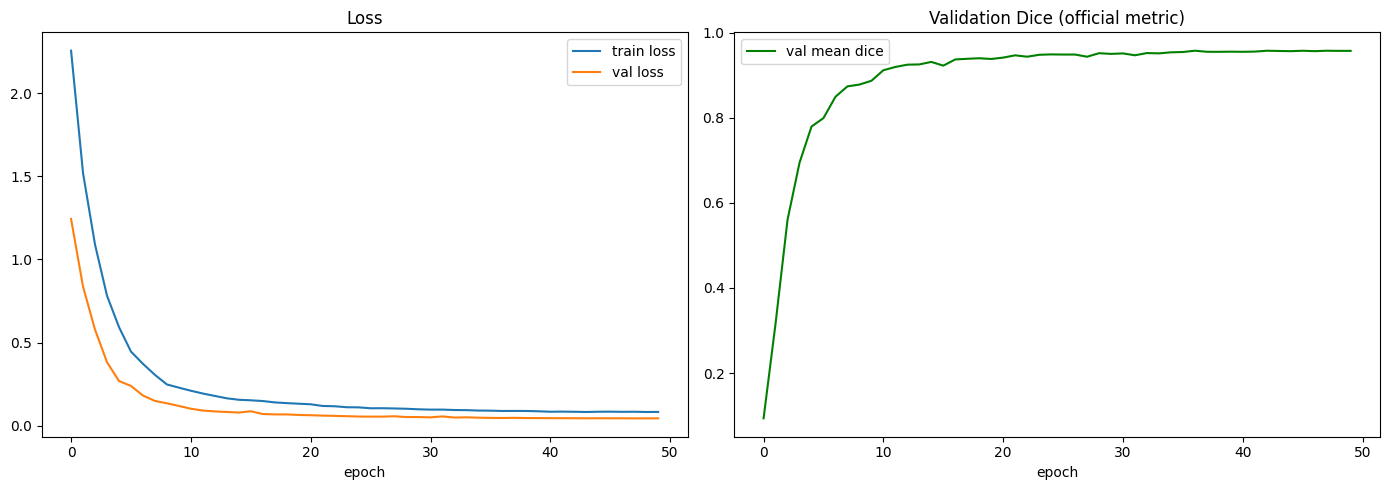

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["val_loss"], label="val loss")
axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(history["val_dice"], label="val mean dice", color="green")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title("Validation Dice (official metric)")
plt.tight_layout()
plt.show()


## Step 6 — Generate predictions

- Reload the best checkpoint (highest val mean Dice, not just lowest loss).
- **Test-time augmentation**: average softmax probabilities over the
  original image plus horizontal and vertical flips, un-flipping the
  predictions before averaging — cheap and reliably improves Dice.
- Encode each of the 6 classes per test image as RLE and write
  `submission.csv` in exactly the `ImageId_ClassId, EncodedPixels` format
  required, using the same RLE convention as `baseline_starter.py` so it's
  guaranteed compatible with the grader.


In [32]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

@torch.no_grad()
def predict_tta(model, img_t, device):
    img_t = img_t.unsqueeze(0).to(device)
    probs_sum = 0
    variants = [
        (lambda x: x, lambda p: p),
        (lambda x: torch.flip(x, [3]), lambda p: torch.flip(p, [3])),
        (lambda x: torch.flip(x, [2]), lambda p: torch.flip(p, [2])),
    ]
    for fwd, inv in variants:
        out = model(fwd(img_t))
        probs = F.softmax(out, dim=1)
        probs_sum = probs_sum + inv(probs)
    probs_avg = probs_sum / len(variants)
    return torch.argmax(probs_avg, dim=1).squeeze(0).cpu().numpy()

rows = []
for fid in te_ids:
    img = np.array(Image.open(f"{CFG.root}/test/images/{fid}").convert("RGB")).astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5
    img_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
    label = predict_tta(model, img_t, device)
    for c in CLASSES:
        m = label == CLASS_ID[c]
        rows.append({"ImageId_ClassId": f"{fid}_{c}", "EncodedPixels": rle_encode(m) if m.any() else ""})

submission = pd.DataFrame(rows)
submission.to_csv(f"{CFG.out_dir}/submission.csv", index=False)
print(submission.shape)
submission.head(12)


(3000, 2)


,ImageId_ClassId,EncodedPixels
0,img_00001.png_hex_nut,17069 6 17451 10 17833 14 18215 18 18597 22 18...
1,img_00001.png_washer,1449 3 1829 12 2210 18 2591 24 2972 30 3354 35...
2,img_00001.png_bolt,32437 11 32820 12 33202 15 33585 20 33614 2 33...
3,img_00001.png_ball_bearing,20273 2 20656 1 20664 1 20666 2 20674 3 20678 ...
4,img_00001.png_spring,19 32 403 33 784 36 1168 36 1550 38 1933 40 23...
5,img_00001.png_o_ring,73502 12 73882 22 74264 26 74645 32 75027 36 7...
6,img_00005.png_hex_nut,75472 13 75848 2 75851 19 76217 37 76599 40 76...
7,img_00005.png_washer,36 72 420 72 803 74 1187 75 1570 76 1953 78 23...
8,img_00005.png_bolt,32841 5 33224 7 33607 12 33990 18 34373 22 347...
9,img_00005.png_ball_bearing,206 57 589 59 972 60 1355 62 1738 64 2122 65 2...


In [33]:
# sanity check: row count/order/keys must match sample_submission.csv exactly
sample_sub = pd.read_csv(f"{CFG.root}/sample_submission.csv")
assert len(submission) == len(sample_sub), "row count mismatch!"
assert set(submission["ImageId_ClassId"]) == set(sample_sub["ImageId_ClassId"]), "key mismatch!"
print("submission.csv matches sample_submission.csv in shape and keys — ready to submit.")


submission.csv matches sample_submission.csv in shape and keys — ready to submit.
